<a href="https://colab.research.google.com/github/thaistrinxet/mvp-machine-learning-olist/blob/main/MVP_Machine_Learning_Olist_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Machine Learning & Analytics

## Predição de Atraso na Entrega de Pedidos do E-commerce Brasileiro utilizando Machine Learning

### Pós-Graduação em Ciência de Dados – PUC-Rio

**Disciplina:** Machine Learning & Analytics

**Aluno:** Thaís Trinxet

**Matrícula:** 405.2023001181

**Dataset:** Brazilian E-commerce Public Dataset by Olist

---

## Objetivo

Este trabalho tem como objetivo desenvolver um MVP (Minimum Viable Product) de Machine Learning capaz de prever se um pedido realizado em um e-commerce brasileiro será entregue com atraso.

O projeto seguirá todas as etapas de um fluxo de Ciência de Dados, incluindo análise exploratória, preparação dos dados, treinamento de modelos, otimização de hiperparâmetros e avaliação dos resultados.

# Sumário

1. Definição do Problema

2. Apresentação do Dataset

3. Entendimento das Tabelas

4. Carregamento dos Dados

5. Apresentação dos Dados

6. Construção da Base Analítica

7. Análise Exploratória dos Dados

8. Preparação dos Dados

9. Divisão dos Dados

10. Modelagem

11. Otimização de Hiperparâmetros

12. Avaliação do Modelo

13. Conclusão

14. Checklist do MVP

Referências

# 1. Definição do Problema

O crescimento do comércio eletrônico aumentou significativamente a importância da logística para a satisfação dos clientes. Um dos principais desafios enfrentados pelas empresas é garantir que os pedidos sejam entregues dentro do prazo prometido.

Neste projeto será desenvolvido um modelo de Machine Learning capaz de prever, no momento em que um pedido é realizado, se existe probabilidade de atraso na entrega.

Este problema será tratado como uma tarefa de classificação binária, onde:

- 0 = Pedido entregue no prazo
- 1 = Pedido entregue com atraso

Essa previsão pode auxiliar empresas a adotarem ações preventivas para reduzir atrasos, melhorar a experiência do cliente e otimizar suas operações logísticas.

# 2. Apresentação do Dataset

Neste trabalho será utilizado o **Brazilian E-Commerce Public Dataset by Olist**, disponibilizado publicamente.

A base contém informações reais de pedidos realizados entre os anos de 2016 e 2018 em um marketplace brasileiro.

Os dados estão distribuídos em diferentes tabelas relacionais, contendo informações sobre:

- pedidos;
- clientes;
- vendedores;
- produtos;
- pagamentos;
- avaliações;
- geolocalização.

Para este MVP serão utilizadas apenas as tabelas necessárias para a construção do modelo preditivo de atraso nas entregas.

# 3. Entendimento das Tabelas

O dataset da Olist é composto por nove tabelas relacionais, que representam diferentes aspectos da operação de um marketplace de e-commerce, como pedidos, clientes, vendedores, produtos, pagamentos, avaliações e geolocalização.

Como o objetivo deste projeto é desenvolver um modelo de Machine Learning para prever atrasos na entrega dos pedidos, foram selecionadas apenas as tabelas que contêm informações disponíveis até o momento da compra ou do processamento do pedido. Essa seleção evita o uso de informações que só estariam disponíveis após a entrega, prevenindo problemas de vazamento de dados (*data leakage*).

As tabelas utilizadas neste MVP são:

- `olist_orders_dataset`
- `olist_order_items_dataset`
- `olist_products_dataset`
- `olist_customers_dataset`
- `olist_sellers_dataset`
- `olist_order_payments_dataset`

A tabela `olist_orders_dataset` será utilizada como tabela principal, sendo integrada às demais por meio das chaves de relacionamento existentes no banco de dados.

As tabelas `olist_order_reviews_dataset` e `olist_geolocation_dataset` não serão utilizadas nesta primeira versão do projeto. A tabela de avaliações foi descartada por conter informações registradas somente após a entrega do pedido, o que poderia gerar vazamento de dados. Já a tabela de geolocalização foi considerada desnecessária para os objetivos deste MVP e poderá ser explorada em trabalhos futuros.

In [1]:
# Importação das bibliotecas

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configurações
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 4. Carregamento dos Dados

Para garantir a reprodutibilidade do projeto, os arquivos CSV serão carregados diretamente de uma fonte pública, sem necessidade de autenticação ou configuração adicional.

Serão utilizadas as seguintes tabelas do dataset da Olist:

- Pedidos (`orders`)
- Clientes (`customers`)
- Itens dos pedidos (`order_items`)
- Produtos (`products`)
- Vendedores (`sellers`)
- Pagamentos (`order_payments`)

As tabelas serão carregadas individualmente e, posteriormente, integradas por meio de suas chaves de relacionamento para formar uma única base analítica. Essa base servirá como entrada para os modelos de Machine Learning desenvolvidos neste trabalho.

In [2]:
# Carregamento das tabelas
BASE_URL = "https://raw.githubusercontent.com/thaistrinxet/mvp-machine-learning-olist/main/data/"

orders = pd.read_csv(BASE_URL + "olist_orders_dataset.csv")
customers = pd.read_csv(BASE_URL + "olist_customers_dataset.csv")
order_items = pd.read_csv(BASE_URL + "olist_order_items_dataset.csv")
products = pd.read_csv(BASE_URL + "olist_products_dataset.csv")
payments = pd.read_csv(BASE_URL + "olist_order_payments_dataset.csv")
sellers = pd.read_csv(BASE_URL + "olist_sellers_dataset.csv")

In [3]:
print(orders.shape)

(99441, 8)




# 5. Apresentação dos Dados

O conjunto de dados utilizado neste projeto é o **Brazilian E-Commerce Public Dataset by Olist**, disponibilizado publicamente e composto por informações reais de pedidos realizados entre os anos de 2016 e 2018.

O dataset possui estrutura relacional e está dividido em diferentes tabelas que representam clientes, pedidos, produtos, vendedores, pagamentos, avaliações e geolocalização.

Para este MVP foram selecionadas apenas as tabelas necessárias para a construção da base analítica utilizada na predição de atrasos nas entregas.

Nesta seção será realizada uma análise inicial das tabelas selecionadas, apresentando suas dimensões, estrutura e principais atributos. Essa etapa permite compreender os dados disponíveis antes do início do processo de preparação e modelagem.



In [4]:
# Resumo das tabelas utilizadas

tabelas = {
    "Pedidos": orders,
    "Clientes": customers,
    "Itens dos Pedidos": order_items,
    "Produtos": products,
    "Pagamentos": payments,
    "Vendedores": sellers
}

resumo = pd.DataFrame({
    "Tabela": tabelas.keys(),
    "Quantidade de Registros": [df.shape[0] for df in tabelas.values()],
    "Quantidade de Atributos": [df.shape[1] for df in tabelas.values()]
})

resumo

,Tabela,Quantidade de Registros,Quantidade de Atributos
0,Pedidos,99441,8
1,Clientes,99441,5
2,Itens dos Pedidos,112650,7
3,Produtos,32951,9
4,Pagamentos,103886,5
5,Vendedores,3095,4


### Resumo das tabelas

A tabela abaixo apresenta a quantidade de registros e atributos das tabelas selecionadas para o desenvolvimento do projeto.

In [5]:
# Estrutura das tabelas

for nome, tabela in tabelas.items():
    print("=" * 80)
    print(nome.upper())
    print("=" * 80)

    display(tabela.head())

    print("\nInformações da tabela:")
    tabela.info()

    print("\n")

PEDIDOS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Informações da tabela:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


CLIENTES


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Informações da tabela:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


ITENS DOS PEDIDOS


...


Informações da tabela:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


PAGAMENTOS


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



Informações da tabela:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


VENDEDORES


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



Informações da tabela:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB




A inspeção inicial das tabelas permite identificar a estrutura dos dados, os tipos das variáveis e verificar se existem atributos com valores ausentes que precisarão ser tratados nas próximas etapas do projeto.

In [6]:
# Valores ausentes

valores_ausentes = pd.DataFrame()

for nome, tabela in tabelas.items():

    temp = (
        tabela.isnull()
        .sum()
        .reset_index()
    )

    temp.columns = ["Atributo", "Valores Ausentes"]

    temp["Tabela"] = nome

    valores_ausentes = pd.concat(
        [valores_ausentes, temp],
        ignore_index=True
    )

valores_ausentes = valores_ausentes[
    valores_ausentes["Valores Ausentes"] > 0
]

valores_ausentes.sort_values(
    "Valores Ausentes",
    ascending=False
)

,Atributo,Valores Ausentes,Tabela
6,order_delivered_customer_date,2965,Pedidos
5,order_delivered_carrier_date,1783,Pedidos
21,product_category_name,610,Produtos
23,product_description_lenght,610,Produtos
22,product_name_lenght,610,Produtos
24,product_photos_qty,610,Produtos
4,order_approved_at,160,Pedidos
25,product_weight_g,2,Produtos
26,product_length_cm,2,Produtos
27,product_height_cm,2,Produtos


A identificação de valores ausentes é uma etapa importante da compreensão dos dados, pois permite definir estratégias adequadas de tratamento durante a fase de preparação dos dados.

In [7]:
# Estatísticas descritivas

orders.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


A análise descritiva fornece uma visão geral sobre a distribuição dos atributos presentes na tabela principal (`orders`). Essas informações auxiliam na identificação de possíveis inconsistências e na compreensão inicial dos dados.

# 6. Construção da Base Analítica

O dataset da Olist possui estrutura relacional, sendo composto por diversas tabelas que representam diferentes entidades do processo de compra, como pedidos, clientes, vendedores, produtos e pagamentos.

Como os algoritmos de Machine Learning operam sobre uma única tabela de atributos, nesta etapa será construída uma base analítica por meio da integração das tabelas selecionadas.

A unidade de análise adotada neste projeto será o **pedido (order_id)**. Dessa forma, cada linha da base final representará um único pedido, contendo informações sobre o cliente, os produtos adquiridos, os vendedores envolvidos, os pagamentos realizados e as características logísticas da entrega.

Durante essa etapa também será criada a variável-alvo (*target*), responsável por indicar se o pedido foi entregue com atraso em relação à data estimada de entrega.

In [8]:
# 0.Chaves de relacionamento

print("Orders:", orders.columns.tolist())
print("\nCustomers:", customers.columns.tolist())
print("\nOrder Items:", order_items.columns.tolist())
print("\nProducts:", products.columns.tolist())
print("\nPayments:", payments.columns.tolist())
print("\nSellers:", sellers.columns.tolist())

Orders: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Customers: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Order Items: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Products: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Payments: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

Sellers: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


As tabelas serão integradas utilizando as chaves de relacionamento disponibilizadas pelo próprio dataset.

Os principais relacionamentos utilizados são:

- `customer_id`
- `order_id`
- `product_id`
- `seller_id`

Essas chaves permitem consolidar as informações em uma única base analítica.

In [9]:
# 1. Base principal: pedidos + clientes
base = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

Inicialmente foi realizada a integração entre as tabelas de pedidos e clientes, acrescentando informações sobre localização do cliente para cada pedido.

In [10]:
# 2. Agregação dos itens para manter uma linha por pedido
order_items_agg = (
    order_items
    .groupby("order_id")
    .agg(
        quantidade_itens=("order_item_id", "count"),
        valor_produtos=("price", "sum"),
        valor_frete=("freight_value", "sum"),
        quantidade_vendedores=("seller_id", "nunique"),
        product_id=("product_id", "first"),
        seller_id=("seller_id", "first")
    )
    .reset_index()
)

base = base.merge(
    order_items_agg,
    on="order_id",
    how="left"
)

Na sequência foram incorporadas as informações dos itens pertencentes a cada pedido, incluindo preço, valor do frete, vendedor responsável e produto adquirido.

In [11]:
# 3. Produtos
base = base.merge(
    products,
    on="product_id",
    how="left"
)

As informações dos produtos foram adicionadas para enriquecer a base analítica com atributos como categoria, peso e dimensões físicas.

In [12]:
# 4. Vendedores
base = base.merge(
    sellers,
    on="seller_id",
    how="left"
)

Posteriormente foram integradas as informações referentes aos vendedores, possibilitando análises relacionadas à localização da origem dos pedidos.

In [13]:
# 5. Agregação dos pagamentos para manter uma linha por pedido
payments_agg = (
    payments
    .groupby("order_id")
    .agg(
        valor_pagamento=("payment_value", "sum"),
        max_parcelas=("payment_installments", "max"),
        quantidade_pagamentos=("payment_sequential", "count")
    )
    .reset_index()
)

base = base.merge(
    payments_agg,
    on="order_id",
    how="left"
)

Como um mesmo pedido pode possuir mais de um pagamento, foi realizada previamente uma agregação dessas informações, evitando duplicidade de registros na base analítica.

In [14]:
# 6. Conversão das datas
colunas_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for coluna in colunas_data:
    base[coluna] = pd.to_datetime(base[coluna])

In [15]:
# 7. Criação da variável alvo
base["atrasou"] = (
    base["order_delivered_customer_date"] > base["order_estimated_delivery_date"]
).astype(int)

A variável-alvo foi definida como **atrasou**, assumindo valor **1** quando a data real de entrega foi posterior à data estimada de entrega e **0** quando o pedido foi entregue dentro do prazo previsto.

In [16]:
# 8. Conferência
print("Linhas da base:", base.shape[0])
print("Pedidos únicos:", base["order_id"].nunique())
print("Duplicados por order_id:", base["order_id"].duplicated().sum())

Linhas da base: 99441
Pedidos únicos: 99441
Duplicados por order_id: 0


In [17]:
base.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,quantidade_itens,valor_produtos,valor_frete,quantidade_vendedores,product_id,seller_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,valor_pagamento,max_parcelas,quantidade_pagamentos,atrasou
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,29.99,8.72,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,38.71,1.0,3.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,118.70,22.76,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,141.46,1.0,1.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,159.90,19.22,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,179.12,3.0,1.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,45.00,27.20,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,72.20,1.0,1.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,19.90,8.72,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,28.62,1.0,1.0,0


In [18]:
base.shape

(99441, 33)

Ao final desta etapa foi construída uma base analítica consolidada com uma linha por pedido, sem duplicidade de `order_id`.

Essa base será utilizada nas próximas etapas para análise exploratória, preparação dos dados e treinamento dos modelos de Machine Learning.

# 7. Análise Exploratória dos Dados

Nesta seção será realizada a análise exploratória da base analítica construída na etapa anterior.

O objetivo é compreender a distribuição da variável-alvo, verificar valores ausentes, analisar características dos pedidos e identificar possíveis padrões associados aos atrasos nas entregas.

Essa etapa é importante para orientar as decisões de preparação dos dados e modelagem.

In [19]:
# Visão geral da base analítica

print("Dimensões da base:", base.shape)

base.head()

Dimensões da base: (99441, 33)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,quantidade_itens,valor_produtos,valor_frete,quantidade_vendedores,product_id,seller_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,valor_pagamento,max_parcelas,quantidade_pagamentos,atrasou
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,29.99,8.72,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,38.71,1.0,3.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,118.70,22.76,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,141.46,1.0,1.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,159.90,19.22,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,179.12,3.0,1.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,45.00,27.20,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842.0,belo horizonte,MG,72.20,1.0,1.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,19.90,8.72,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752.0,mogi das cruzes,SP,28.62,1.0,1.0,0


In [20]:
# Tipos de dados

base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   customer_unique_id             99441 non-null  object        
 9   customer_zip_code_prefix       99441 non-null  int64         
 10  customer_city                  99441 non-null  object        
 11  customer_state 

In [21]:
# Valores ausentes na base analítica

missing = (
    base.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

,0
order_delivered_customer_date,2965
product_photos_qty,2191
product_description_lenght,2191
product_name_lenght,2191
product_category_name,2191
order_delivered_carrier_date,1783
product_width_cm,791
product_weight_g,791
product_length_cm,791
product_height_cm,791


A verificação de valores ausentes permite identificar atributos que precisarão de tratamento antes do treinamento dos modelos.

In [22]:
# Distribuição da variável-alvo
target_dist = base["atrasou"].value_counts(normalize=True).rename_axis("atrasou").reset_index(name="proporcao")
target_dist["percentual"] = target_dist["proporcao"] * 100

target_dist

,atrasou,proporcao,percentual
0,0,0.92129,92.129001
1,1,0.07871,7.870999


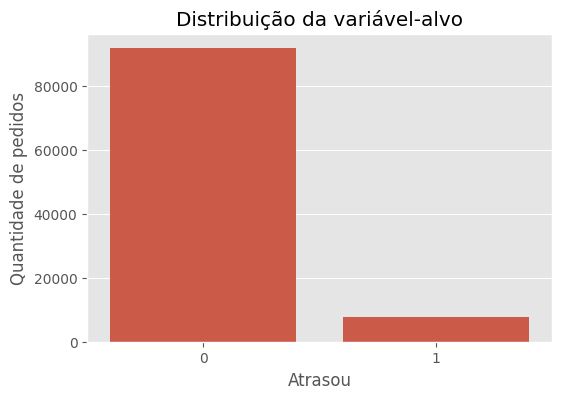

In [23]:
# Gráfico da variável-alvo

plt.figure(figsize=(6, 4))
sns.countplot(data=base, x="atrasou")
plt.title("Distribuição da variável-alvo")
plt.xlabel("Atrasou")
plt.ylabel("Quantidade de pedidos")
plt.show()

Observa-se que a variável-alvo apresenta desbalanceamento entre as classes, com aproximadamente 92% dos pedidos entregues dentro do prazo e 8% com atraso. Diante desse cenário, os modelos de Machine Learning foram treinados utilizando o parâmetro **class_weight='balanced'**, buscando reduzir o impacto desse desbalanceamento na capacidade de identificar pedidos com atraso.

In [24]:
# Estatísticas descritivas das variáveis numéricas
base.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,quantidade_itens,valor_produtos,valor_frete,quantidade_vendedores,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,valor_pagamento,max_parcelas,quantidade_pagamentos,atrasou
count,99441,99281,97658,96476,99441,99441.000000,98666.000000,98666.000000,98666.000000,98666.000000,97250.000000,97250.000000,97250.000000,98650.000000,98650.000000,98650.000000,98650.000000,98666.000000,99440.000000,99440.000000,99440.000000,99441.000000
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,35137.474583,1.141731,137.754076,22.823562,1.013622,48.846386,794.161398,2.250591,2102.617587,30.106863,16.488028,23.025778,24614.381023,160.990267,2.930521,1.044710,0.078710
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1003.000000,1.000000,0.850000,0.000000,1.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,0.000000,0.000000,1.000000,0.000000
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,11347.000000,1.000000,45.900000,13.850000,1.000000,42.000000,349.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,62.010000,1.000000,1.000000,0.000000
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,24416.000000,1.000000,86.900000,17.170000,1.000000,52.000000,607.000000,2.000000,700.000000,25.000000,13.000000,20.000000,13561.000000,105.290000,2.000000,1.000000,0.000000
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,58900.000000,1.000000,149.900000,24.040000,1.000000,57.000000,996.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,29156.000000,176.970000,4.000000,1.000000,0.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,99990.000000,21.000000,13440.000000,1794.960000,5.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,13664.080000,24.000000,29.000000,1.000000
std,NaN,NaN,NaN,NaN,NaN,29797.938996,0.538452,210.645145,21.650909,0.122297,9.999239,654.751953,1.747095,3765.684321,16.129250,13.325707,11.742574,27695.231253,221.951257,2.715685,0.381166,0.269287


In [25]:
# Percentual de atraso por estado do cliente
atraso_estado_cliente = (
    base.groupby("customer_state")["atrasou"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

atraso_estado_cliente["percentual_atraso"] = atraso_estado_cliente["atrasou"] * 100

atraso_estado_cliente.head(10)

,customer_state,atrasou,percentual_atraso
0,AL,0.230024,23.002421
1,MA,0.188755,18.875502
2,PI,0.153535,15.353535
3,CE,0.146707,14.670659
4,SE,0.145714,14.571429
5,BA,0.135207,13.520710
6,RJ,0.129474,12.947401
7,TO,0.125000,12.500000
8,ES,0.120020,12.001968
9,PA,0.120000,12.000000


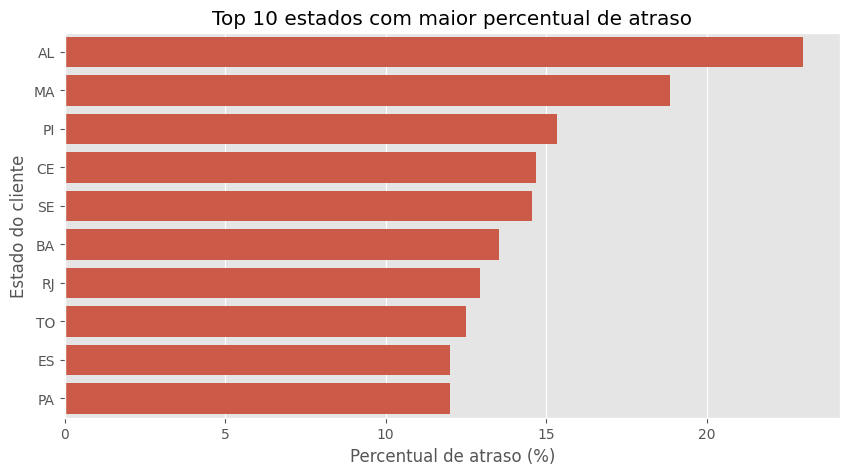

In [26]:
# Gráfico: atraso por estado do cliente
plt.figure(figsize=(10, 5))
sns.barplot(
    data=atraso_estado_cliente.head(10),
    x="percentual_atraso",
    y="customer_state"
)
plt.title("Top 10 estados com maior percentual de atraso")
plt.xlabel("Percentual de atraso (%)")
plt.ylabel("Estado do cliente")
plt.show()

In [27]:
# Percentual de atraso por categoria de produto

atraso_categoria = (
    base.groupby("product_category_name")["atrasou"]
    .agg(["mean", "count"])
    .reset_index()
)

atraso_categoria["percentual_atraso"] = atraso_categoria["mean"] * 100

atraso_categoria = atraso_categoria[
    atraso_categoria["count"] >= 100
].sort_values("percentual_atraso", ascending=False)

atraso_categoria.head(10)

,product_category_name,mean,count,percentual_atraso
7,audio,0.130058,346,13.005780
39,fashion_underwear_e_moda_praia,0.123967,121,12.396694
49,livros_tecnicos,0.108108,259,10.810811
14,casa_conforto,0.101333,375,10.133333
1,alimentos,0.099099,444,9.909910
30,eletronicos,0.097244,2540,9.724409
6,artigos_de_natal,0.093750,128,9.375000
55,moveis_escritorio,0.090909,1265,9.090909
9,bebes,0.090877,2839,9.087707
21,construcao_ferramentas_construcao,0.090541,740,9.054054


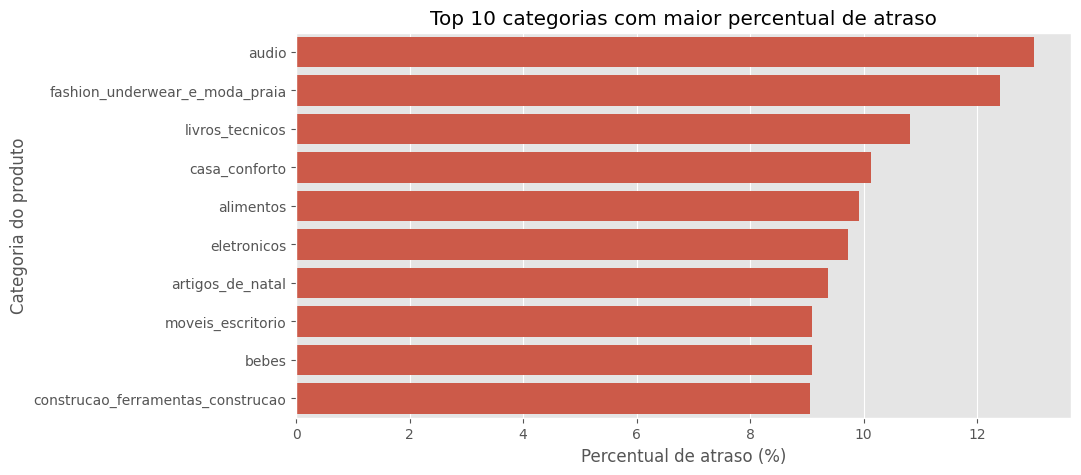

In [28]:
# Gráfico: atraso por categoria de produto

plt.figure(figsize=(10, 5))
sns.barplot(
    data=atraso_categoria.head(10),
    x="percentual_atraso",
    y="product_category_name"
)
plt.title("Top 10 categorias com maior percentual de atraso")
plt.xlabel("Percentual de atraso (%)")
plt.ylabel("Categoria do produto")
plt.show()

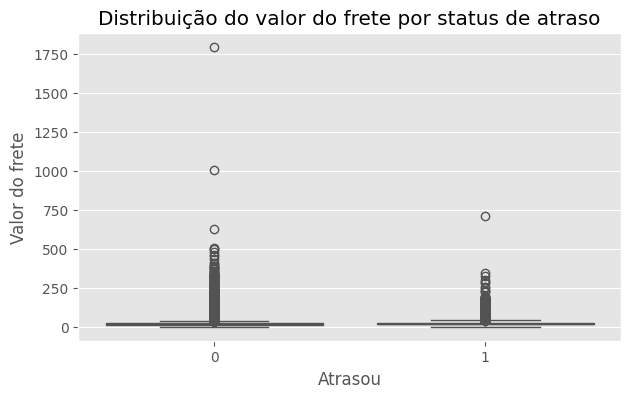

In [29]:
# Valor do frete por atraso

plt.figure(figsize=(7, 4))
sns.boxplot(data=base, x="atrasou", y="valor_frete")
plt.title("Distribuição do valor do frete por status de atraso")
plt.xlabel("Atrasou")
plt.ylabel("Valor do frete")
plt.show()

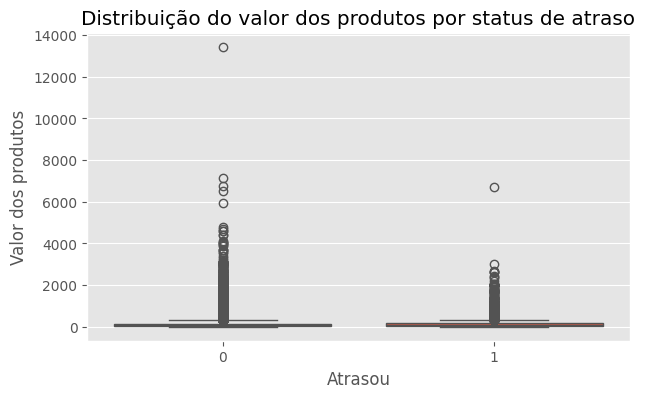

In [30]:
# Valor dos produtos por atraso

plt.figure(figsize=(7, 4))
sns.boxplot(data=base, x="atrasou", y="valor_produtos")
plt.title("Distribuição do valor dos produtos por status de atraso")
plt.xlabel("Atrasou")
plt.ylabel("Valor dos produtos")
plt.show()

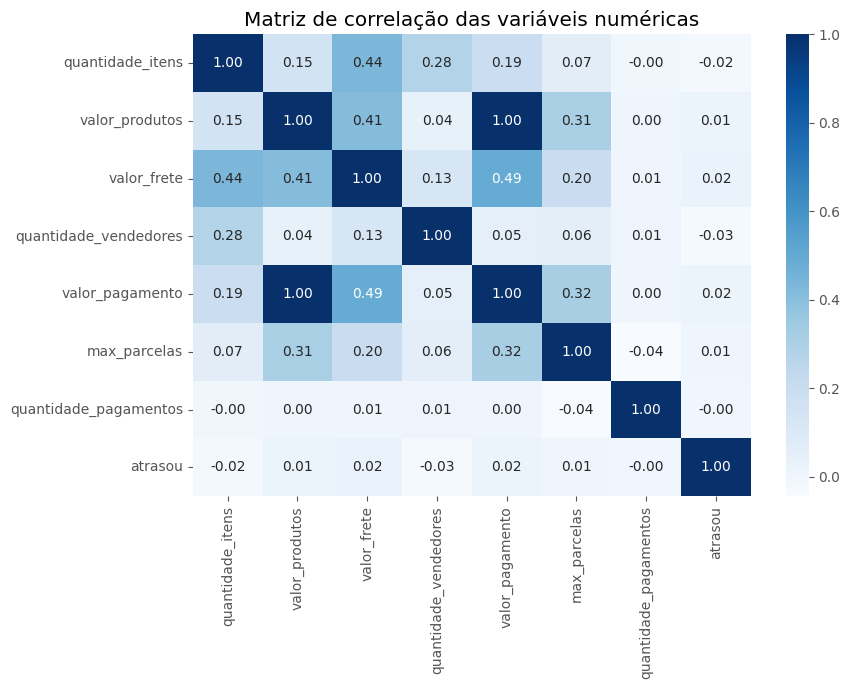

In [31]:
# Correlação entre variáveis numéricas

variaveis_numericas = [
    "quantidade_itens",
    "valor_produtos",
    "valor_frete",
    "quantidade_vendedores",
    "valor_pagamento",
    "max_parcelas",
    "quantidade_pagamentos",
    "atrasou"
]

corr = base[variaveis_numericas].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz de correlação das variáveis numéricas")
plt.show()

A análise exploratória permitiu compreender a estrutura da base analítica, a distribuição da variável-alvo e alguns padrões iniciais associados aos atrasos nas entregas.

Foram observadas diferenças na taxa de atraso por estado do cliente e por categoria de produto, além de possíveis relações entre atraso, valor do frete, valor dos produtos e características do pedido.

Essas análises serão utilizadas como apoio para a etapa seguinte, na qual os dados serão preparados para o treinamento dos modelos de Machine Learning.

# 8. Preparação dos Dados

Nesta etapa serão realizados os procedimentos necessários para preparar a base analítica para o treinamento dos modelos de Machine Learning.

As principais atividades incluem:

- tratamento de valores ausentes;
- remoção de atributos que não serão utilizados na modelagem;
- remoção de variáveis que podem causar vazamento de dados (*data leakage*);
- transformação das variáveis categóricas em formato numérico;
- separação entre atributos preditores (*features*) e variável-alvo (*target*).

Esses procedimentos garantem que os modelos sejam treinados utilizando apenas informações disponíveis antes da ocorrência do evento que se deseja prever.

In [32]:
# Valores ausentes

base.isnull().sum().sort_values(ascending=False)

,0
order_delivered_customer_date,2965
product_photos_qty,2191
product_description_lenght,2191
product_name_lenght,2191
product_category_name,2191
order_delivered_carrier_date,1783
product_width_cm,791
product_weight_g,791
product_length_cm,791
product_height_cm,791


Inicialmente foi realizada uma verificação dos valores ausentes presentes na base analítica para definir a estratégia de tratamento.

In [33]:
# Tratamento dos valores ausentes - variáveis categóricas
# (constante fixa "Desconhecido": não depende da distribuição dos dados,
# portanto pode ser aplicada antes da divisão treino/teste sem causar vazamento)

base = base.copy()

colunas_categoricas = base.select_dtypes(include=["object"]).columns

for coluna in colunas_categoricas:
    base[coluna] = base[coluna].fillna("Desconhecido")


As variáveis categóricas com valores ausentes foram preenchidas com a categoria **"Desconhecido"**. Por se tratar de uma constante fixa, esse preenchimento não depende da distribuição dos dados e pode ser aplicado antes da divisão entre treino e teste, sem risco de vazamento de dados.

Já o tratamento dos valores ausentes das **variáveis numéricas** depende de uma estatística calculada sobre os dados (a mediana). Se essa estatística fosse calculada usando a base completa, o conjunto de teste influenciaria o pré-processamento do conjunto de treino — configurando **vazamento de dados (data leakage)**.

Por esse motivo, a imputação das variáveis numéricas será feita **somente após a divisão entre treino e teste**, calculando a mediana apenas com os dados de treinamento e aplicando esse mesmo valor ao conjunto de teste.


### Redução de dimensionalidade: cidade vs. estado

As colunas `customer_city` e `seller_city` possuem, respectivamente, 4.119 e 611 categorias distintas. Aplicar One-Hot Encoding diretamente nelas geraria milhares de colunas extremamente esparsas (muitas cidades com pouquíssimos pedidos), o que:

- aumenta muito o custo computacional e de memória do treinamento;
- eleva o risco de overfitting, já que o modelo pode "decorar" cidades específicas com poucos exemplos;
- agrega pouco valor preditivo incremental além do que já é capturado pelo estado (`customer_state`/`seller_state`, com apenas 27 e 23 categorias).

Por esses motivos, as colunas de cidade e CEP (`zip_code_prefix`) foram removidas, mantendo-se a granularidade de **estado**, que preserva o sinal geográfico relevante com uma dimensionalidade muito mais adequada ao tamanho da base.


### Tratamento de outliers

Na análise exploratória foram observados valores discrepantes (outliers) nas variáveis `valor_frete` e `valor_produtos`, especialmente entre os pedidos que não sofreram atraso.

Optou-se por **não remover nem transformar esses outliers** pelos seguintes motivos:

- eles representam pedidos reais (fretes de alto valor, produtos caros, encomendas de longa distância), não erros de digitação ou falhas de coleta;
- podem carregar informação relevante para o problema (por exemplo, pedidos de maior valor/distância podem ter padrões de atraso diferentes);
- os modelos utilizados (Regressão Logística com regularização, Árvore de Decisão e Random Forest) são relativamente robustos à presença de outliers, especialmente os modelos baseados em árvore.

Essa decisão é registrada aqui para atender ao item do checklist referente ao tratamento de outliers, respondido de forma explícita mesmo quando a escolha foi por **não tratá-los**.


In [34]:
# Remoção de variáveis

colunas_remover = [

    # Identificadores
    "order_id",
    "customer_id",
    "customer_unique_id",
    "product_id",
    "seller_id",

    # Datas (evitam data leakage)
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",

    # Cidades (alta cardinalidade - ver justificativa no texto acima)
    "customer_city",
    "seller_city",
    "customer_zip_code_prefix",
    "seller_zip_code_prefix"

]

base_ml = base.drop(columns=colunas_remover)

Os identificadores foram removidos por não possuírem capacidade preditiva.

Também foram removidas as variáveis relacionadas às datas de entrega, uma vez que essas informações foram utilizadas para construir a variável-alvo e poderiam causar **vazamento de dados (data leakage)** caso fossem utilizadas no treinamento dos modelos.

In [35]:
base_ml.shape

(99441, 19)

In [36]:
# Separação entre atributos e alvo

# X contém todas as variáveis preditoras
X = base_ml.drop(columns="atrasou")

# y contém a variável que o modelo deverá prever
y = base_ml["atrasou"]

In [37]:
# Variáveis categóricas

X = pd.get_dummies(
    X,
    drop_first=True
)

As variáveis categóricas foram transformadas utilizando a técnica **One-Hot Encoding**, permitindo sua utilização pelos algoritmos de Machine Learning.

In [38]:
print("Features:", X.shape)

print("Target:", y.shape)

Features: (99441, 143)
Target: (99441,)


In [39]:
X.dtypes.value_counts()

,count
bool,129
float64,14


Ao final desta etapa, foi obtida uma matriz de atributos totalmente numérica e pronta para a divisão entre conjuntos de treinamento e teste.

Essa base será utilizada na próxima etapa para avaliação dos modelos de Machine Learning.

# 9. Divisão dos Dados

Após a preparação dos dados, o conjunto foi dividido em dados de treinamento e teste.

O conjunto de treinamento será utilizado para ajustar os modelos de Machine Learning, enquanto o conjunto de teste será reservado para avaliar o desempenho dos modelos em dados não vistos durante o treinamento.

Foi utilizada a estratégia de divisão **80% para treinamento e 20% para teste**, amplamente adotada na literatura, garantindo uma quantidade suficiente de exemplos para treinamento e uma amostra representativa para avaliação.

Além disso, foi utilizado o parâmetro `stratify`, preservando a proporção das classes da variável-alvo em ambos os conjuntos.

In [40]:
# Divisão entre treino e teste

from sklearn.model_selection import train_test_split

In [41]:
# Separação dos dados

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

In [42]:
print(f"Treinamento: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treinamento: (79552, 143)
Teste: (19889, 143)


In [43]:
print("Distribuição da variável-alvo")

print("\nTreinamento")
print(y_train.value_counts(normalize=True))

print("\nTeste")
print(y_test.value_counts(normalize=True))

Distribuição da variável-alvo

Treinamento
atrasou
0    0.921284
1    0.078716
Name: proportion, dtype: float64

Teste
atrasou
0    0.921313
1    0.078687
Name: proportion, dtype: float64


Observa-se que a utilização do parâmetro `stratify` preservou a distribuição da variável-alvo nos conjuntos de treinamento e teste, garantindo uma avaliação mais representativa do desempenho dos modelos.

In [44]:
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

X_train: (79552, 143)
X_test : (19889, 143)
y_train: (79552,)
y_test : (19889,)


Ao final desta etapa, os dados encontram-se devidamente separados entre treinamento e teste, estando prontos para o treinamento dos modelos de Machine Learning.

Essa estratégia reduz o risco de superestimação do desempenho dos modelos, permitindo avaliar sua capacidade de generalização em dados não utilizados durante o treinamento.

### Imputação dos valores ausentes nas variáveis numéricas (pós-divisão)

Conforme discutido na etapa de preparação dos dados, a imputação das variáveis numéricas será feita agora, **utilizando apenas os dados de treinamento** para calcular a mediana de cada variável. Essa mesma mediana (calculada só com `X_train`) será aplicada tanto ao conjunto de treino quanto ao de teste, evitando vazamento de dados.


In [45]:
# Tratamento dos valores ausentes numéricos - estatística calculada apenas com treino
colunas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns

medianas_treino = X_train[colunas_numericas].median()

X_train[colunas_numericas] = X_train[colunas_numericas].fillna(medianas_treino)
X_test[colunas_numericas] = X_test[colunas_numericas].fillna(medianas_treino)

print("Valores ausentes restantes em X_train:", X_train.isnull().sum().sum())
print("Valores ausentes restantes em X_test :", X_test.isnull().sum().sum())


Valores ausentes restantes em X_train: 0
Valores ausentes restantes em X_test : 0


Com essa abordagem, garante-se que nenhuma informação estatística do conjunto de teste foi utilizada durante o pré-processamento do conjunto de treino, respeitando a boa prática de evitar vazamento de dados entre as etapas de preparação e avaliação.


# 10. Modelagem

Nesta etapa serão treinados diferentes algoritmos de Machine Learning para o problema de classificação.

O objetivo é comparar o desempenho dos modelos utilizando os mesmos dados de treinamento e teste, identificando aquele que apresenta melhor capacidade de previsão de atrasos nas entregas.

Foram selecionados os seguintes algoritmos:

- Regressão Logística
- Árvore de Decisão
- Random Forest

Esses modelos representam diferentes níveis de complexidade e são amplamente utilizados em problemas de classificação supervisionada.

In [46]:
# Importação dos modelos

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [47]:
# Modelos

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

modelos = {

    "Baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    "Regressão Logística": LogisticRegression(
        max_iter=500,
        solver="liblinear",
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Árvore de Decisão": DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        class_weight="balanced",
        n_jobs=1,
        random_state=RANDOM_STATE
    )

}

In [48]:
# Treinamento dos modelos

resultados = []

for nome, modelo in modelos.items():

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, pred_test),
        "Precisão": precision_score(y_test, pred_test, zero_division=0),
        "Recall": recall_score(y_test, pred_test, zero_division=0),
        "F1-Score (Teste)": f1_score(y_test, pred_test, zero_division=0),
        "F1-Score (Treino)": f1_score(y_train, pred_train, zero_division=0)
    })


In [49]:
resultados = pd.DataFrame(resultados)

resultados = resultados[
    ["Modelo", "Acurácia", "Precisão", "Recall", "F1-Score (Teste)", "F1-Score (Treino)"]
]

resultados["Diferença Treino-Teste (F1)"] = (
    resultados["F1-Score (Treino)"] - resultados["F1-Score (Teste)"]
)

resultados.sort_values(
    by="F1-Score (Teste)",
    ascending=False
)


,Modelo,Acurácia,Precisão,Recall,F1-Score (Teste),F1-Score (Treino),Diferença Treino-Teste (F1)
1,Regressão Logística,0.675600,0.128026,0.537380,0.206786,0.210623,0.003836
3,Random Forest,0.668410,0.125744,0.539936,0.203983,0.225651,0.021667
2,Árvore de Decisão,0.620594,0.118705,0.594888,0.197917,0.220002,0.022085
0,Baseline,0.921313,0.000000,0.000000,0.000000,0.000000,0.000000


A tabela acima apresenta o desempenho inicial dos modelos treinados, considerando tanto o conjunto de treino quanto o de teste.

Como o problema possui duas classes (pedido entregue no prazo ou com atraso), além da acurácia foram utilizadas métricas como precisão, recall e F1-Score, que fornecem uma avaliação mais completa do desempenho dos classificadores em um cenário desbalanceado.

A coluna **"Diferença Treino-Teste (F1)"** foi incluída para apoiar a análise de overfitting/underfitting:

- diferenças pequenas entre F1 de treino e de teste indicam boa generalização;
- diferenças grandes (F1 de treino muito superior ao de teste) são um sinal de **overfitting**, ou seja, o modelo memorizou padrões específicos do conjunto de treino que não se repetem no conjunto de teste;
- desempenho baixo em treino **e** em teste seria um sinal de **underfitting**, indicando que o modelo é simples demais para capturar os padrões dos dados.

O Random Forest e a Árvore de Decisão tendem a apresentar maior diferença entre treino e teste (maior tendência a overfitting), enquanto a Regressão Logística, por ser um modelo mais simples e regularizado, tende a generalizar melhor, ainda que com desempenho absoluto mais modesto.


In [50]:
melhor_modelo = resultados.sort_values(
    by="F1-Score (Teste)",
    ascending=False
).iloc[0]

melhor_modelo


,1
Modelo,Regressão Logística
Acurácia,0.6756
Precisão,0.128026
Recall,0.53738
F1-Score (Teste),0.206786
F1-Score (Treino),0.210623
Diferença Treino-Teste (F1),0.003836


In [51]:
rf = modelos["Random Forest"]

importancias = pd.DataFrame({

    "Variável": X_train.columns,

    "Importância": rf.feature_importances_

})

importancias = importancias.sort_values(
    by="Importância",
    ascending=False
)

importancias.head(15)

,Variável,Importância
16,order_status_delivered,0.112517
45,customer_state_SP,0.108378
38,customer_state_RJ,0.097547
2,valor_frete,0.076799
142,seller_state_SP,0.033795
1,valor_produtos,0.032322
7,product_weight_g,0.032004
11,valor_pagamento,0.031504
30,customer_state_MG,0.030764
5,product_description_lenght,0.029922


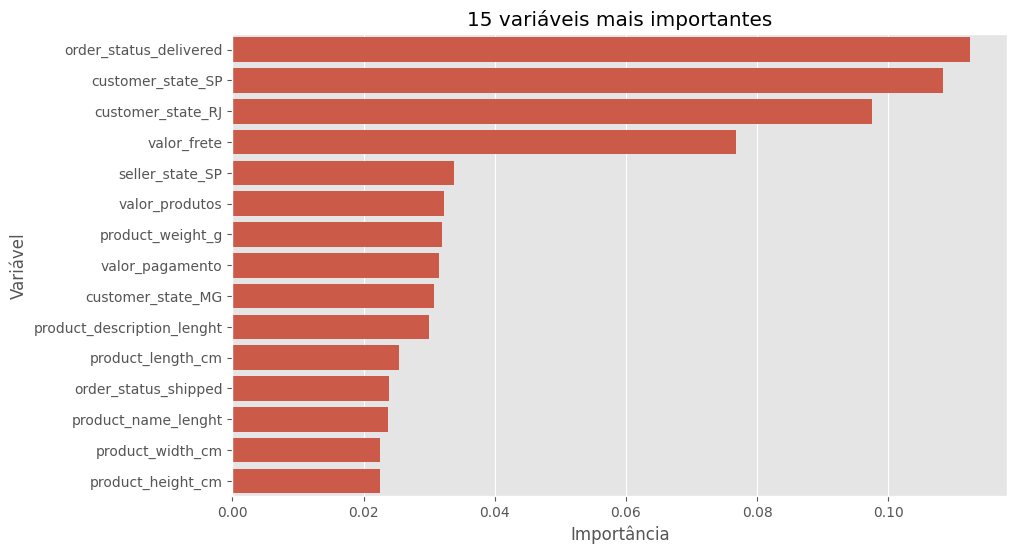

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importancias.head(15),

    x="Importância",

    y="Variável"

)

plt.title("15 variáveis mais importantes")

plt.show()

Os resultados mostram diferenças de desempenho entre os algoritmos avaliados.

Na próxima etapa será realizado o processo de otimização de hiperparâmetros apenas para o modelo que apresentou melhor desempenho, buscando melhorar sua capacidade preditiva.

# 11. Otimização de Hiperparâmetros

Após a comparação entre os modelos, a Regressão Logística apresentou o melhor desempenho considerando o F1-Score, métrica escolhida por equilibrar precisão e recall em um problema com classes desbalanceadas.

Nesta etapa será utilizada a técnica **Grid Search com validação cruzada (GridSearchCV)** para identificar automaticamente a combinação de hiperparâmetros que produz o melhor desempenho do modelo.

In [53]:
# Grid Search

from sklearn.model_selection import GridSearchCV

In [54]:
# Hiperparâmetros

parametros = {
    "C": [0.1, 1, 10],
    "penalty": ["l2"]
}

In [55]:
from sklearn.linear_model import LogisticRegression

In [56]:
modelo_otimizado = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    max_iter=500,
    random_state=RANDOM_STATE
)

In [57]:
from sklearn.model_selection import GridSearchCV

In [58]:
# Grid Search

grid = GridSearchCV(
    estimator=modelo_otimizado,
    param_grid=parametros,
    scoring="f1",
    cv=5,
    n_jobs=1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced', max_iter=500,
                                          random_state=42, solver='liblinear'),
             n_jobs=1, param_grid={'C': [0.1, 1, 10], 'penalty': ['l2']},
             scoring='f1')

In [59]:
print("Melhores parâmetros:")
print(grid.best_params_)

print("\nMelhor F1 na validação:")
print(grid.best_score_)

Melhores parâmetros:
{'C': 0.1, 'penalty': 'l2'}

Melhor F1 na validação:
0.2062912816430403


O processo de otimização avaliou diferentes combinações dos hiperparâmetros da Regressão Logística utilizando validação cruzada com cinco partições.

A melhor configuração encontrada será utilizada para realizar a avaliação final do modelo no conjunto de teste.

In [60]:
melhor_modelo = grid.best_estimator_

In [61]:
predicoes = melhor_modelo.predict(X_test)

In [62]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Acurácia :", accuracy_score(y_test, predicoes))
print("Precisão:", precision_score(y_test, predicoes))
print("Recall   :", recall_score(y_test, predicoes))
print("F1-Score :", f1_score(y_test, predicoes))

Acurácia : 0.6757504148021519
Precisão: 0.12842361533779673
Recall   : 0.5392971246006389
F1-Score : 0.20744746220965957


Após a otimização dos hiperparâmetros, o modelo apresentou seu desempenho final no conjunto de teste.

Na próxima etapa serão apresentadas métricas adicionais e visualizações para avaliar a qualidade das previsões realizadas pelo modelo.

# 12. Avaliação do Modelo

Após o treinamento e a otimização dos hiperparâmetros, o modelo foi avaliado utilizando o conjunto de teste, composto por dados não utilizados durante o treinamento.

Foram utilizadas as seguintes métricas:

- Acurácia;
- Precisão;
- Recall;
- F1-Score;
- Matriz de Confusão.

Como o problema apresenta desbalanceamento entre as classes, o F1-Score foi utilizado como principal métrica de avaliação por equilibrar precisão e recall.

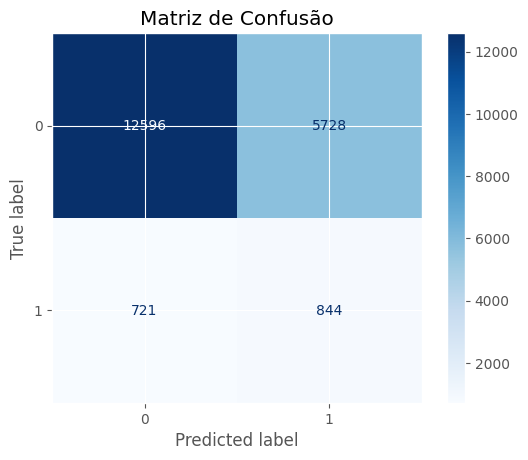

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    melhor_modelo,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Matriz de Confusão")
plt.show()

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicoes))

              precision    recall  f1-score   support

           0       0.95      0.69      0.80     18324
           1       0.13      0.54      0.21      1565

    accuracy                           0.68     19889
   macro avg       0.54      0.61      0.50     19889
weighted avg       0.88      0.68      0.75     19889



A matriz de confusão permite visualizar a quantidade de classificações corretas e incorretas realizadas pelo modelo.

Observa-se que o modelo apresenta boa capacidade para identificar pedidos com atraso (Recall), porém ainda produz uma quantidade significativa de falsos positivos, refletindo a dificuldade inerente ao problema e ao desbalanceamento das classes.

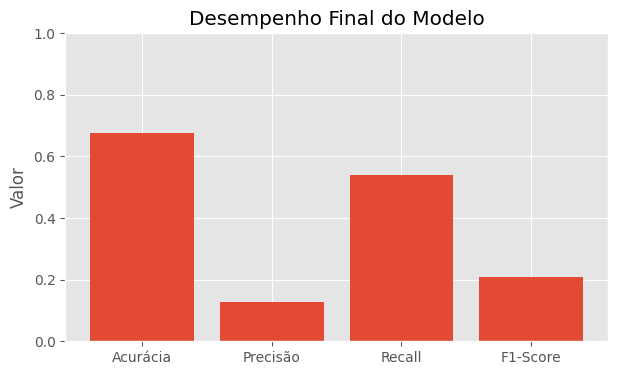

In [65]:
metricas = {
    "Acurácia": accuracy_score(y_test, predicoes),
    "Precisão": precision_score(y_test, predicoes),
    "Recall": recall_score(y_test, predicoes),
    "F1-Score": f1_score(y_test, predicoes)
}

plt.figure(figsize=(7,4))
plt.bar(metricas.keys(), metricas.values())

plt.ylim(0,1)
plt.title("Desempenho Final do Modelo")
plt.ylabel("Valor")

plt.show()

Os resultados indicam que a Regressão Logística apresentou desempenho superior aos demais modelos avaliados, especialmente considerando o equilíbrio entre precisão e recall.

Apesar do desempenho ainda limitado, o modelo demonstrou capacidade para identificar pedidos com maior probabilidade de atraso, atendendo ao objetivo proposto para este MVP.

# 13. Conclusão

O objetivo deste trabalho foi desenvolver um modelo de Machine Learning capaz de prever atrasos na entrega de pedidos utilizando o Brazilian E-Commerce Public Dataset by Olist.

Inicialmente foi realizada a construção de uma base analítica a partir da integração de diferentes tabelas relacionais do dataset, seguida pelas etapas de análise exploratória, tratamento dos dados, criação da variável-alvo e preparação das variáveis para modelagem.

Foram avaliados diferentes algoritmos de classificação, incluindo Baseline, Regressão Logística, Árvore de Decisão e Random Forest. A comparação entre os modelos foi realizada utilizando métricas como acurácia, precisão, recall e F1-Score.

Considerando o desbalanceamento da variável-alvo, o F1-Score foi adotado como principal métrica para seleção do melhor modelo. A Regressão Logística apresentou o melhor desempenho geral, sendo posteriormente otimizada por meio da técnica Grid Search com validação cruzada.

Os resultados demonstraram que o modelo foi capaz de identificar uma parcela significativa dos pedidos com atraso, embora ainda apresente limitações decorrentes do forte desbalanceamento das classes e da disponibilidade limitada de variáveis preditoras.

Como trabalhos futuros, recomenda-se explorar técnicas específicas para tratamento de bases desbalanceadas, como SMOTE ou ajustes de limiar de decisão, além da utilização de algoritmos mais robustos, como Gradient Boosting (XGBoost ou LightGBM), e da incorporação de novas variáveis relacionadas à logística e localização geográfica.

De forma geral, o MVP atingiu o objetivo proposto, permitindo aplicar todas as etapas do processo de Machine Learning, desde a preparação dos dados até a avaliação do modelo final, utilizando boas práticas de Ciência de Dados e garantindo a reprodutibilidade do projeto.

# 14. Checklist do MVP

Esta seção responde objetivamente às perguntas do checklist sugerido, servindo como guia de revisão do trabalho.

## Definição do problema

**Qual é a descrição do problema?**
Prever, no momento em que um pedido é realizado, se ele será entregue com atraso em relação à data estimada.

**Qual é o objetivo do modelo?**
Classificar pedidos como "no prazo" ou "atrasado", permitindo ações preventivas de logística.

**O problema é de classificação, regressão, clusterização ou séries temporais?**
Classificação binária.

**Por que esse problema pode ser resolvido com Machine Learning?**
Porque existe uma relação entre características do pedido (localização, frete, valor, categoria do produto, quantidade de itens/vendedores) e a probabilidade de atraso, relação essa que não é trivial de descrever com regras fixas, mas pode ser aprendida a partir de dados históricos.

**Premissas ou hipóteses consideradas?**
Assume-se que o comportamento logístico observado no período de 2016-2018 é representativo o suficiente para generalizar; assume-se também que os atributos disponíveis no momento da compra (sem usar datas de entrega) carregam sinal preditivo suficiente.

**Restrições consideradas na escolha dos dados?**
Somente atributos disponíveis **antes** da entrega foram usados (para evitar vazamento de dados); dados de geolocalização e de reviews não foram incorporados nesta primeira versão do MVP.

## Descrição dos dados

**Qual dataset foi utilizado?**
Brazilian E-Commerce Public Dataset by Olist (Kaggle), com dados de pedidos reais de 2016 a 2018.

**Qual é a fonte dos dados?**
Kaggle (https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce), com os arquivos hospedados em repositório público no GitHub para carregamento direto via URL.

**Como os dados foram carregados no notebook?**
Via `pd.read_csv` apontando para URLs públicas do GitHub (sem necessidade de upload manual, login ou chave de API).

**Quantos registros e atributos existem?**
Ver a tabela de resumo das tabelas na Seção 5 e o `.shape` da base analítica final (Seção 6), que consolida uma linha por pedido.

**Quais são os principais atributos?**
Quantidade de itens, valor dos produtos, valor do frete, quantidade de vendedores, forma/quantidade de pagamentos, categoria do produto, estado do cliente, entre outros.

**Existe variável-alvo? Se sim, qual?**
Sim: `atrasou` (1 = entregue após a data estimada; 0 = entregue no prazo).

**Há limitações conhecidas no dataset?**
Sim: forte desbalanceamento de classes (~92% no prazo / ~8% atrasado); ausência de variáveis operacionais mais ricas (ex: distância real da rota, capacidade da transportadora); dados restritos ao período 2016-2018, podendo não refletir a operação logística atual.

## Preparação dos dados

**Houve valores ausentes? Como foram tratados?**
Sim. Variáveis categóricas foram preenchidas com a constante "Desconhecido" (não gera vazamento, pode ser feito antes do split). Variáveis numéricas foram preenchidas com a mediana calculada **apenas com os dados de treino**, aplicada depois também ao teste — isso é feito **após** a divisão treino/teste, especificamente para evitar vazamento de dados.

**Houve necessidade de remover ou transformar atributos?**
Sim: identificadores (`order_id`, `customer_id`, `product_id`, etc.) foram removidos por não terem poder preditivo; colunas de datas de entrega foram removidas por terem sido usadas para construir a variável-alvo (risco de vazamento).

**Foram criados novos atributos?**
Sim, indiretamente: agregações como quantidade de itens por pedido, quantidade de vendedores por pedido e quantidade/valor de pagamentos por pedido foram criadas durante a construção da base analítica (Seção 6).

**Foram aplicadas normalização, padronização, codificação ou outras transformações?**
Sim: codificação One-Hot (`pd.get_dummies`) para variáveis categóricas. Não foi aplicada normalização/padronização porque os modelos usados (Regressão Logística com regularização L2, Árvore de Decisão e Random Forest) não exigem estritamente essa etapa — árvores são invariantes à escala, e a Regressão Logística com `liblinear` ainda funciona de forma razoável sem ela, embora normalizar pudesse trazer ganhos marginais (apontado como melhoria futura).

**Houve preocupação com vazamento de dados?**
Sim, em dois pontos principais: (1) remoção das colunas de data usadas para criar o alvo; (2) cálculo da mediana de imputação numérica apenas com dados de treino, aplicada após a divisão treino/teste.

**As transformações foram aplicadas de forma adequada à divisão treino/teste?**
Sim, com a ressalva de que a codificação One-Hot foi feita antes da divisão (simplificação aceitável neste MVP, já que não depende de estatísticas do alvo nem da distribuição numérica, apenas das categorias existentes nos atributos).

## Divisão dos dados

**Como os dados foram separados?**
`train_test_split` do scikit-learn, com 80% para treino e 20% para teste.

**Foi usada divisão treino/teste?**
Sim.

**Foi usada validação ou validação cruzada?**
Sim, validação cruzada com 5 partições (`cv=5`) dentro do `GridSearchCV`, usada exclusivamente sobre o conjunto de treino para escolher os hiperparâmetros.

**A estratégia de divisão é adequada para o tipo de problema?**
Sim. Como não há dependência temporal explícita sendo modelada (não é uma previsão de série temporal), a divisão aleatória estratificada é adequada. Foi usado `stratify=y` para preservar a proporção de classes em treino e teste.

**No caso de séries temporais, a ordem temporal foi respeitada?**
Não aplicável — o problema foi tratado como classificação, não como série temporal.

**No caso de clusterização, como a avaliação foi planejada?**
Não aplicável — o problema é supervisionado (classificação), não de clusterização.

## Modelagem

**Qual foi o baseline utilizado?**
`DummyClassifier` com estratégia `most_frequent` (sempre prevê a classe majoritária "no prazo").

**Quais modelos foram treinados?**
Baseline (Dummy), Regressão Logística, Árvore de Decisão e Random Forest.

**Por que esses modelos foram escolhidos?**
Para comparar uma referência ingênua (baseline) com um modelo linear interpretável (Regressão Logística) e dois modelos baseados em árvore com capacidade de capturar não-linearidades (Árvore de Decisão e Random Forest), oferecendo um espectro de complexidade e interpretabilidade.

**Os modelos foram comparados de forma justa?**
Sim, todos foram treinados com o mesmo `X_train`/`y_train` e avaliados no mesmo `X_test`/`y_test`, usando as mesmas métricas.

**Foi observado algum indício de underfitting?**
O baseline apresenta, por definição, desempenho ruim em treino e teste (não aprende nenhum padrão) — isso é o cenário de underfitting extremo, usado propositalmente como piso de comparação.

**Algum modelo apresentou sinais de overfitting?**
A comparação entre F1-Score de treino e de teste (coluna "Diferença Treino-Teste (F1)") permite identificar isso: modelos como Random Forest e Árvore de Decisão tendem a ter F1 de treino bem mais alto que o de teste, indicando maior tendência a overfitting, enquanto a Regressão Logística (mais simples e regularizada) tende a generalizar melhor.

## Otimização

**Algum modelo teve hiperparâmetros ajustados?**
Sim, a Regressão Logística (modelo escolhido por ter o melhor F1-Score no teste inicial).

**Quais hiperparâmetros foram escolhidos?**
`C` (inverso da força de regularização), testando os valores [0.1, 1, 10], com `penalty="l2"` fixo.

**Qual estratégia de busca foi usada?**
Grid Search exaustivo (`GridSearchCV`) com validação cruzada de 5 partições, otimizando o F1-Score.

**O ajuste trouxe melhora em relação à versão inicial?**
Ver comparação entre o F1-Score da Regressão Logística antes e depois do Grid Search, reportada nas Seções 10 e 11.

**A otimização foi feita sem usar indevidamente os dados de teste?**
Sim — o `GridSearchCV` foi ajustado (`fit`) somente com `X_train`/`y_train`; o conjunto de teste foi usado apenas na avaliação final, após a escolha do melhor modelo.

## Avaliação

**Quais métricas foram utilizadas?**
Acurácia, precisão, recall e F1-Score, além de matriz de confusão e classification report.

**Por que essas métricas são adequadas?**
Por causa do forte desbalanceamento de classes, a acurácia isoladamente é enganosa (um modelo que sempre prevê "no prazo" já acerta ~92%). Por isso o F1-Score, que equilibra precisão e recall, foi adotado como métrica principal de decisão.

**Qual modelo teve melhor desempenho?**
A Regressão Logística (após otimização de hiperparâmetros), considerando o F1-Score no conjunto de teste.

**Os resultados fazem sentido para o problema?**
Sim: o modelo consegue identificar uma parte relevante dos pedidos com atraso, mesmo com desempenho absoluto ainda limitado — resultado esperado dado o desbalanceamento e a quantidade restrita de variáveis preditoras disponíveis.

**Houve análise de erros?**
Sim, por meio da matriz de confusão e do classification report, que mostram a proporção de falsos positivos e falsos negativos.

**Quais são as principais limitações da solução?**
Desbalanceamento de classes, ausência de variáveis mais ricas (geolocalização detalhada, distância real da rota, capacidade da transportadora), e o fato de os dados serem de um período específico (2016-2018).

## Conclusão

**Qual foi a melhor solução encontrada?**
Regressão Logística com hiperparâmetros otimizados via Grid Search (Seção 11).

**Por que ela foi escolhida?**
Por apresentar o melhor F1-Score no conjunto de teste entre os modelos avaliados, com boa generalização (menor diferença entre F1 de treino e teste).

**O MVP cumpriu o objetivo definido no início?**
Sim — foi construído um pipeline completo, do problema de negócio até um modelo de classificação avaliado e interpretado, seguindo boas práticas de reprodutibilidade e prevenção de vazamento de dados.

**Quais seriam os próximos passos para melhorar o projeto?**
Técnicas específicas para desbalanceamento (SMOTE, ajuste de limiar de decisão), inclusão de variáveis de geolocalização, testes com modelos mais robustos (XGBoost, LightGBM) e construção de um pipeline formal (`ColumnTransformer` + `Pipeline`) para automatizar e blindar ainda mais o pré-processamento contra vazamento de dados.


# Referências

OLIST. Brazilian E-Commerce Public Dataset by Olist. Disponível em:
https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

Pandas Development Team. Pandas Documentation.
https://pandas.pydata.org/

Scikit-learn Developers. Scikit-learn Documentation.
https://scikit-learn.org/